<a href="https://colab.research.google.com/github/KK-code001/Candidate-Screening-System/blob/main/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the datasets
train_df = pd.read_csv('train_data.csv')
test_df = pd.read_csv('test_data.csv')

# 2. Preprocessing
train_df['shortlisted'] = train_df['shortlisted'].map({'Yes': 1, 'No': 0})
test_df['shortlisted'] = test_df['shortlisted'].map({'Yes': 1, 'No': 0})

train_df = pd.get_dummies(train_df, columns=['education_level'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['education_level'], drop_first=True)

# Ensure test set columns match training set
for col in set(train_df.columns) - set(test_df.columns):
    test_df[col] = 0

test_df = test_df[train_df.columns]

# Features and Target
X_train = train_df.drop('shortlisted', axis=1)
y_train = train_df['shortlisted']

X_test = test_df.drop('shortlisted', axis=1)
y_test = test_df['shortlisted']

# 3. Apply Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=500,# number of trees
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

# 4. Predict
y1=rf_model.predict(X_train)
y_pred = rf_model.predict(X_test)

# 5. Evaluate Performance
test_acc = accuracy_score(y_test, y_pred)
train_acc = accuracy_score(y_train, y1)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training Accuracy: 0.9062
Testing Accuracy: 0.8818

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.88      0.82      1832
           1       0.95      0.88      0.91      4168

    accuracy                           0.88      6000
   macro avg       0.86      0.88      0.87      6000
weighted avg       0.89      0.88      0.88      6000



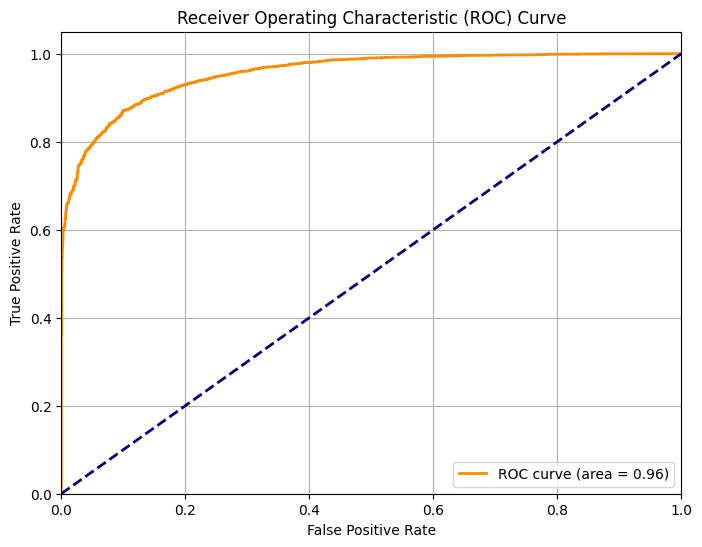

ROC AUC Score: 0.9562


In [4]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities for the test set
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

In [ ]:
from sklearn.metrics import classification_report

# Calculate the classification report as a dictionary
report_dict = classification_report(y_test, y_pred, output_dict=True)

# Convert the classification report dictionary to a DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# Save the DataFrame to a CSV file
report_csv_path = 'classification_report.csv'
report_df.to_csv(report_csv_path, index=True)

print(f"Classification report saved to {report_csv_path}")

Classification report saved to classification_report.csv


In [ ]:
from google.colab import files

# Download the generated CSV file
files.download('classification_report.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>